# Optimizer Comparison

In this notebook, we evaluate different optimizers for our current training pipeline, which uses blurred backgrounds, the **DINOv3** backbone, and the combined **ProxyAnchor + Center Loss**. A suitable optimizer should not only improve **identity-balanced mAP** on the validation set but also accelerate training and produce a stable training curve.

For each optimizer, we reinitialize the embedding projection model and monitor its **identity-balanced mAP** on the validation set. Each optimizer requires specific hyperparameters, which we selected based on prior knowledge and adjusted to ensure smooth training. A dedicated follow-up study with systematic hyperparameter tuning would be beneficial.

The notebook is structured as follows:

1. **Adam**
2. **AdamW**
3. **NAdam**
4. **SGD + Momentum**
5. **RMSProp**


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters needed for the subsequent exploratory data analysis.

In [ ]:
EXPERIMENT_NAME = "05_optimize_comparison"
RANDOM_SEED = 334 # 12, 67, 99, 87, 334

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    ArcFaceLoss,
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset, ImageDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 334 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [ ]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # Adam
    "adam_learning_rate": 1e-3,
    "adam_weight_decay": 1e-4,

    # AdamW
    "adamw_learning_rate": 1e-3,
    "adamw_weight_decay": 1e-4,

    # NAdam
    "nadam_learning_rate": 1e-3,  # similar to Adam
    "nadam_weight_decay": 1e-4,
    "nadam_momentum_decay": 0.004,  # default NAdam momentum

    # SGD
    "sgd_learning_rate": 1e-2,   # SGD usually needs higher LR
    "sgd_weight_decay": 1e-4,
    "sgd_momentum": 0.9,         # standard momentum

    # RMSprop
    "rmsprop_learning_rate": 1e-3,  # similar scale to Adam
    "rmsprop_weight_decay": 1e-4,
    "rmsprop_momentum": 0.9,        # typical RMSprop momentum

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Scheduler
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  adam_learning_rate: 0.001
  adam_weight_decay: 0.0001
  adamw_learning_rate: 0.001
  adamw_weight_decay: 0.01
  nadam_learning_rate: 0.001
  nadam_weight_decay: 0.0001
  nadam_momentum_decay: 0.004
  sgd_learning_rate: 0.01
  sgd_weight_decay: 0.0001
  sgd_momentum: 0.9
  rmsprop_learning_rate: 0.001
  rmsprop_weight_decay: 0.0001
  rmsprop_momentum: 0.9
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 334


In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


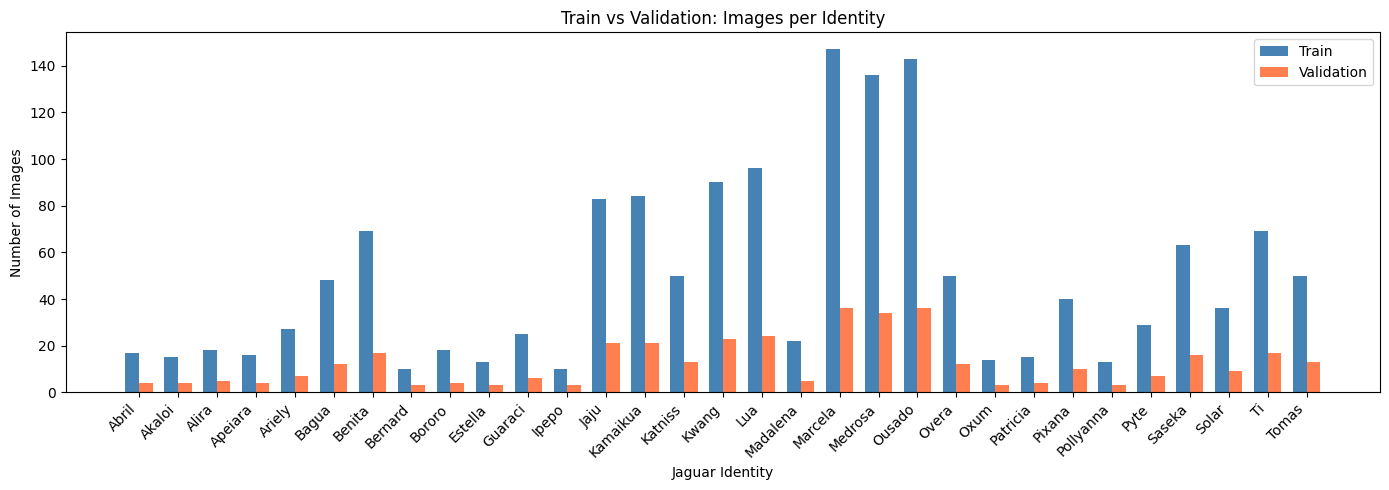


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [ ]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda


In [ ]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [ ]:
image_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [ ]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


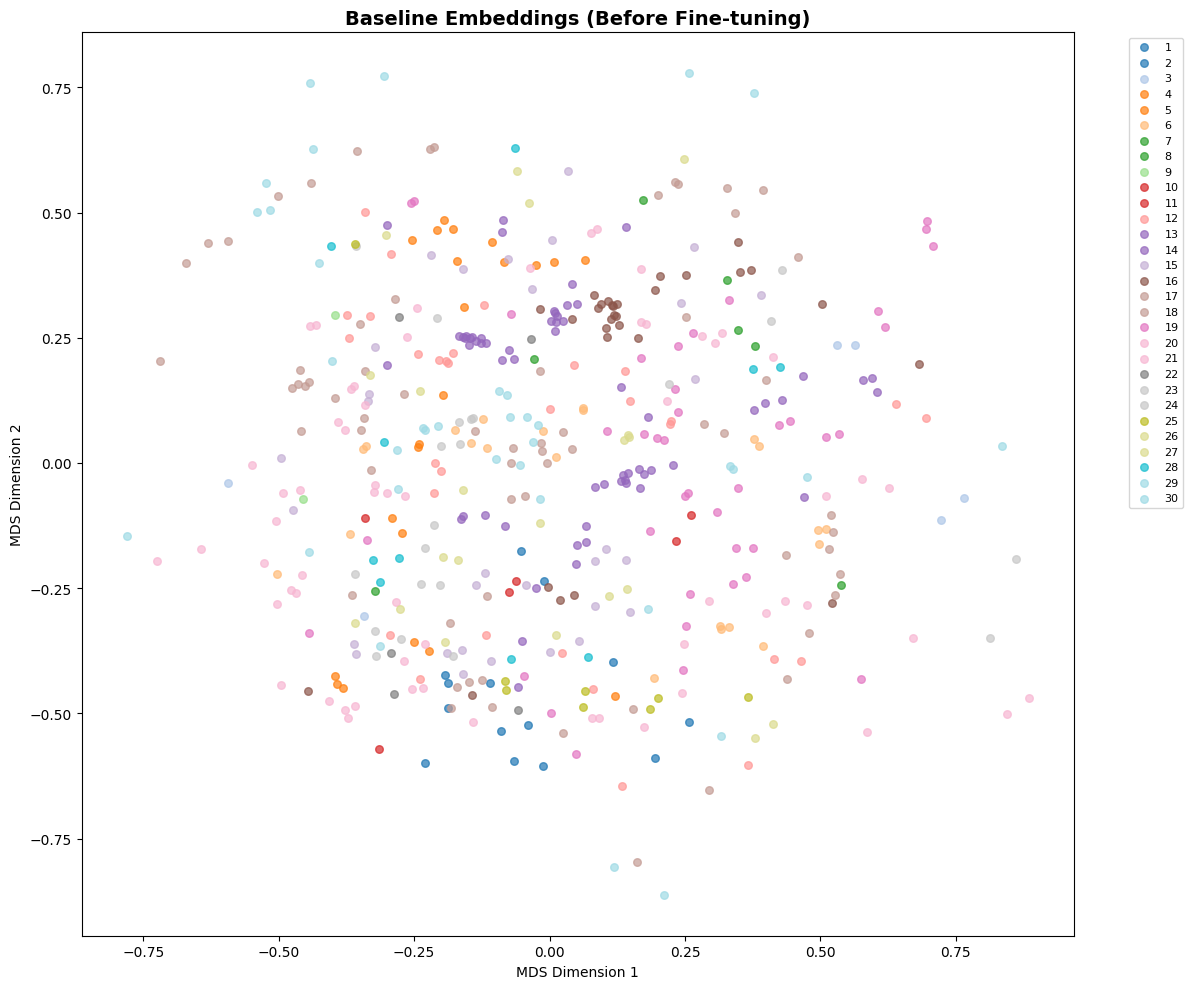

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [16]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


During comparison, we initialize each experiment with the same model weights to ensure that differences in performance are not influenced by variations in initialization.

In [17]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/optimizer/model_initial_weights.pth


In [ ]:
criterion = CombinedLoss(
    first_loss=ProxyAnchorLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"], 
        margin=config["proxyanchor_margin"], 
        alpha=config["proxyanchor_alpha"]
    ),
    second_loss=CenterLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

print(f"Combined Loss: ProxyAnchor + CenterLoss")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")
print(f"  Lambda: {config['proxyanchor_lambda']}")

Since **ProxyAnchor Loss** includes learnable proxy vectors, these vectors must be reset before retraining the embedding projection model.

In [ ]:
criterion_checkpoint_path = CHECKPOINT_PATH / "criterion_initial_state.pth"
torch.save(criterion.state_dict(), criterion_checkpoint_path)
print(f"Initial criterion state saved to {criterion_checkpoint_path}")

In [ ]:
table = [
    ["Optimizer", "Best val_mAP", "Best epoch", "Training time"]
]

## Adam

Adam (Adaptive Moment Estimation) is an optimization algorithm that combines momentum with adaptive learning rates. It maintains running estimates of both the first moment (mean) and second moment (variance) of gradients, allowing each parameter to have its own learning rate. This typically leads to faster and more stable convergence.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))
criterion.load_state_dict(torch.load(criterion_checkpoint_path))

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["adam_learning_rate"],
    weight_decay=config["adam_weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"], 
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss + CenterLoss")
print(f"  Optimizer: Adam (lr={config['adam_learning_rate']}, weight_decay={config['adam_weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: Adam (lr=0.001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
adam_checkpoint_path = CHECKPOINT_PATH / "best_adam_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="adam",
    checkpoint_path=adam_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_adam": best_map,
    "best_epoch_adam": best_epoch,
    "total_epochs_adam": len(history['train_loss']),
    "training_time_adam": training_time
})

table.append([
    "Adam",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 334 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 8.9042
  Val Loss:   7.2413
  Val mAP:    0.3418 | LR: 1.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 7.5803
  Val Loss:   6.6764
  Val mAP:    0.3485 | LR: 1.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 7.0374
  Val Loss:   6.1867
  Val mAP:    0.3587 | LR: 1.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 6.4445
  Val Loss:   5.5083
  Val mAP:    0.3824 | LR: 1.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1648
  Val Loss:   1.0008
  Val mAP:    0.8427 | LR: 1.00e-03
  No improvement. Patience: 6/10

Epoch 41/200


  Train Loss: 0.1750
  Val Loss:   0.9363
  Val mAP:    0.8457 | LR: 1.00e-03
  No improvement. Patience: 7/10

Epoch 42/200


  Train Loss: 0.1762
  Val Loss:   1.0278
  Val mAP:    0.8258 | LR: 1.00e-03
  No improvement. Patience: 8/10

Epoch 43/200


  Train Loss: 0.1497
  Val Loss:   0.9575
  Val mAP:    0.8450 | LR: 1.00e-03
  No improvement. Patience: 9/10

Epoch 44/200


  Train Loss: 0.1433
  Val Loss:   0.9481
  Val mAP:    0.8420 | LR: 1.00e-03
  No improvement. Patience: 10/10

Early stopping triggered after 44 epochs

Training complete!
Best epoch: 34, Val mAP: 0.8520


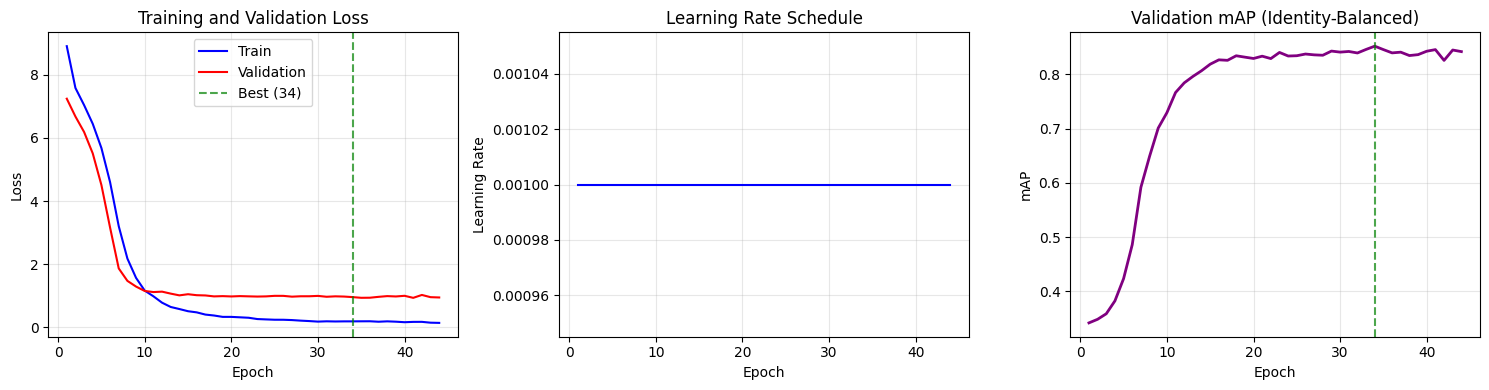

In [22]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_adam.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_adam": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(adam_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 34
  Val Loss: 0.9595
  Val mAP: 0.8520


In [24]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


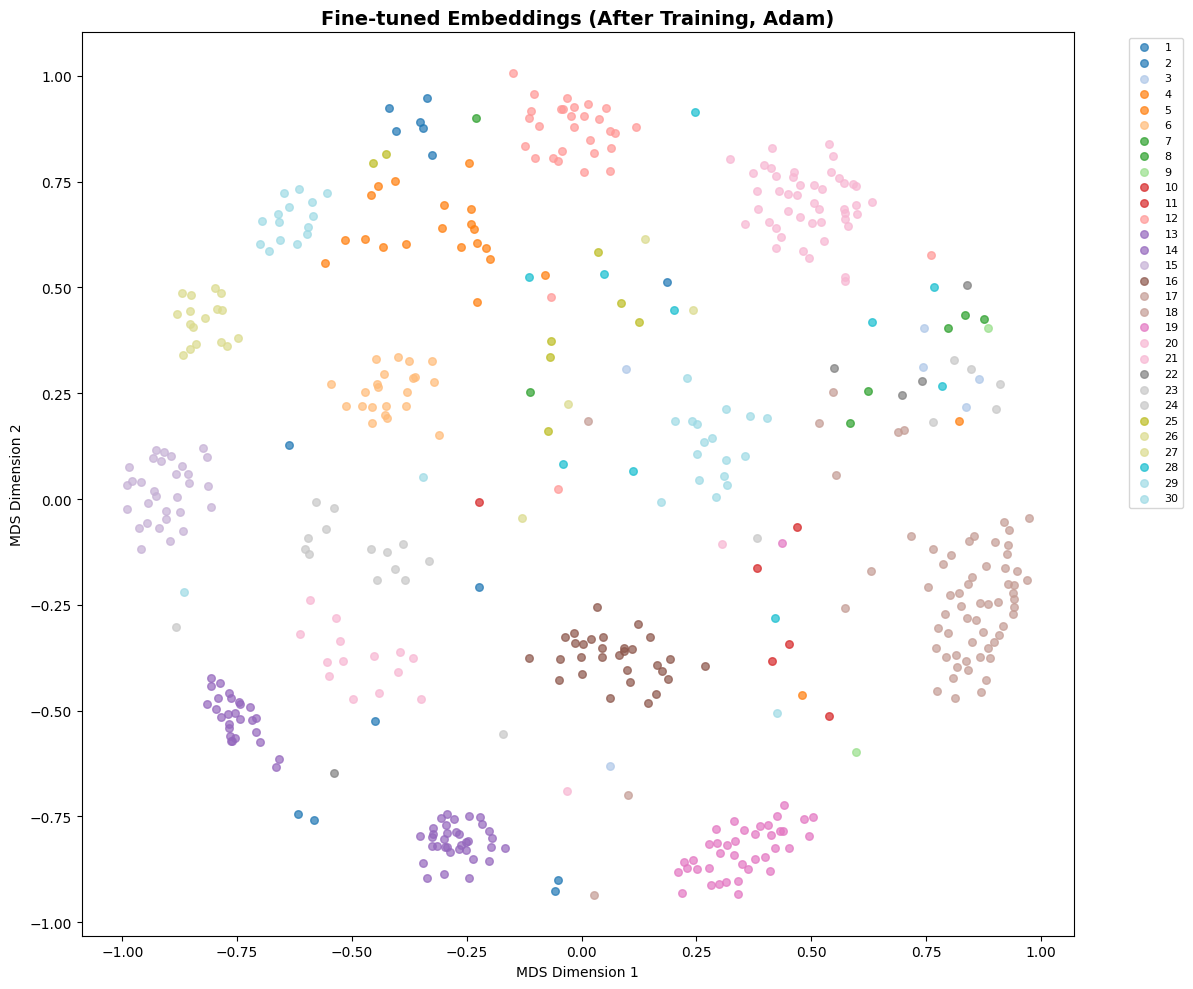

In [25]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, Adam)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "adam_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_adam": wandb.Image(fig_finetuned)})

In [ ]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_adam.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_adam": wandb.Image(fig),
    "nearest_neighbors_stats_adam": stats,
})


In [26]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## AdamW

AdamW is a variant of Adam that decouples weight decay from the gradient update. Instead of incorporating weight decay into the gradient calculation, it applies it directly to the weights. This modification improves regularization and often leads to better generalization in deep learning models.


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))
criterion.load_state_dict(torch.load(criterion_checkpoint_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["adamw_learning_rate"],
    weight_decay=config["adamw_weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['adamw_learning_rate']}, weight_decay={config['adamw_weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Optimizer: AdamW (lr=0.001, weight_decay=0.01)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
adamw_checkpoint_path = CHECKPOINT_PATH / "best_adamw_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="adamw",
    checkpoint_path=adamw_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_adamw": best_map,
    "best_epoch_adamw": best_epoch,
    "total_epochs_adamw": len(history['train_loss']),
    "training_time_adamw": training_time
})

table.append([
    "AdamW",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 334 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 8.4279
  Val Loss:   6.4756
  Val mAP:    0.3512 | LR: 1.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 6.5372
  Val Loss:   5.1148
  Val mAP:    0.3773 | LR: 1.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 5.3878
  Val Loss:   3.7775
  Val mAP:    0.4242 | LR: 1.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 4.2094
  Val Loss:   2.5764
  Val mAP:    0.4999 | LR: 1.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.0881
  Val Loss:   0.9393
  Val mAP:    0.8446 | LR: 6.25e-05
  No improvement. Patience: 6/10

Epoch 50/200


  Train Loss: 0.0833
  Val Loss:   0.9440
  Val mAP:    0.8440 | LR: 6.25e-05
  No improvement. Patience: 7/10

Epoch 51/200


  Train Loss: 0.0846
  Val Loss:   0.9388
  Val mAP:    0.8460 | LR: 6.25e-05
  No improvement. Patience: 8/10

Epoch 52/200


  Train Loss: 0.0891
  Val Loss:   0.9527
  Val mAP:    0.8426 | LR: 6.25e-05
  No improvement. Patience: 9/10

Epoch 53/200


  Train Loss: 0.0875
  Val Loss:   0.9340
  Val mAP:    0.8460 | LR: 3.13e-05
  No improvement. Patience: 10/10

Early stopping triggered after 53 epochs

Training complete!
Best epoch: 43, Val mAP: 0.8485


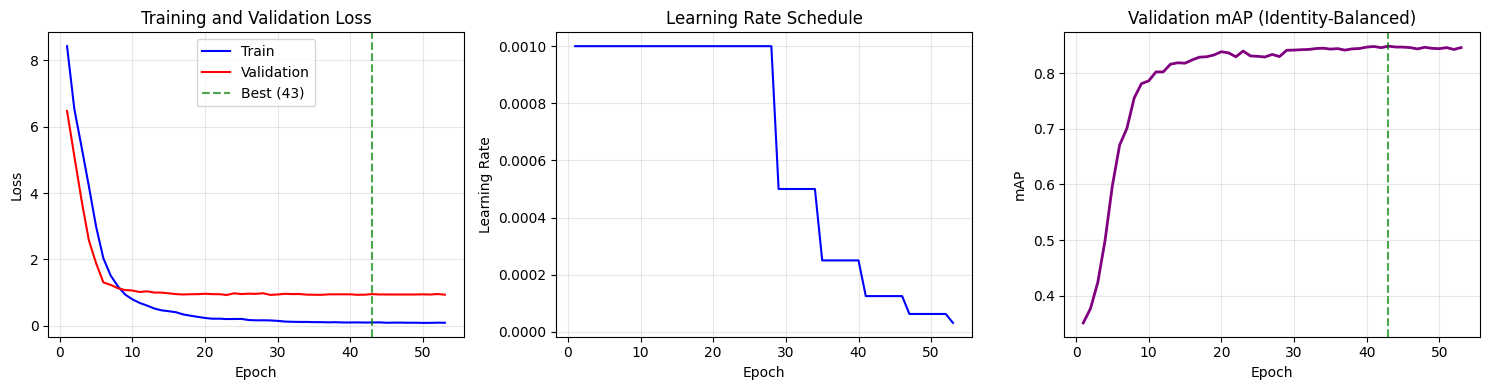

In [29]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_adamw.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_adamw": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(adamw_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 43
  Val Loss: 0.9510
  Val mAP: 0.8485


In [31]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


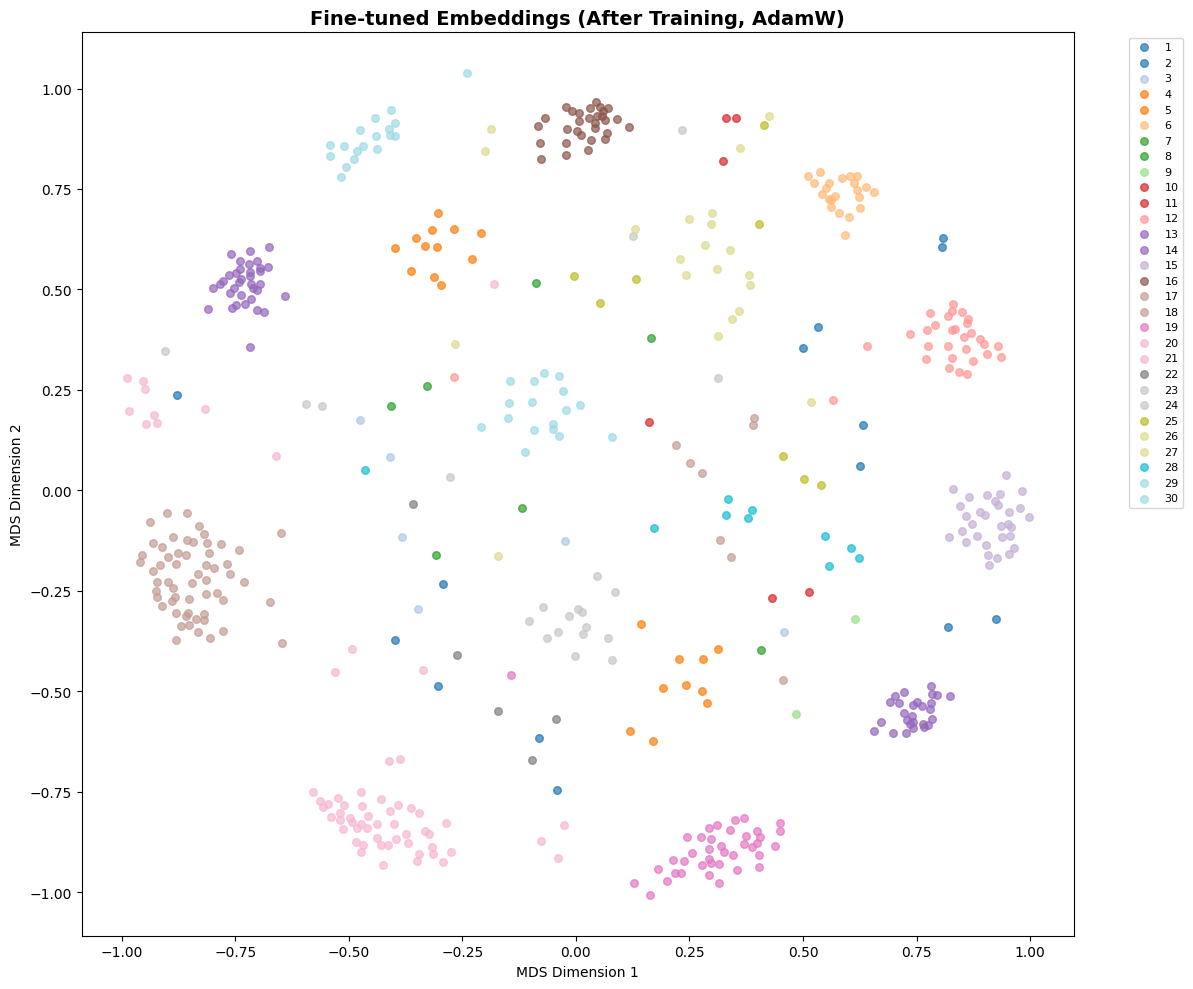

In [32]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, AdamW)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "adamw_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_adamw": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_adamw.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_adamw": wandb.Image(fig),
    "nearest_neighbors_stats_adamw": stats,
})


In [33]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## NAdam

NAdam (Nesterov-accelerated Adam) integrates Nesterov momentum into the Adam optimizer. By incorporating a look-ahead gradient update, it anticipates future parameter positions, which can improve convergence speed and stability during training.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))
criterion.load_state_dict(torch.load(criterion_checkpoint_path))

optimizer = torch.optim.NAdam(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["nadam_learning_rate"],
    weight_decay=config["nadam_weight_decay"],
    momentum_decay=config["nadam_momentum_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: NAdam (lr={config['nadam_learning_rate']}, weight_decay={config['nadam_weight_decay']}, momentum_decay={config['nadam_momentum_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Optimizer: NAdam (lr=0.001, weight_decay=0.0001, momentum_decay=0.004)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
nadam_checkpoint_path = CHECKPOINT_PATH / "best_nadam_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="nadam",
    checkpoint_path=nadam_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_nadam": best_map,
    "best_epoch_nadam": best_epoch,
    "total_epochs_nadam": len(history['train_loss']),
    "training_time_nadam": training_time
})

table.append([
    "NAdam",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 334 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 8.3107
  Val Loss:   6.5436
  Val mAP:    0.3668 | LR: 1.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 6.4147
  Val Loss:   5.1806
  Val mAP:    0.4096 | LR: 1.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 5.1284
  Val Loss:   3.6065
  Val mAP:    0.4714 | LR: 1.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 3.7985
  Val Loss:   2.6834
  Val mAP:    0.5605 | LR: 1.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1975
  Val Loss:   0.9677
  Val mAP:    0.8395 | LR: 1.00e-03
  No improvement. Patience: 6/10

Epoch 28/200


  Train Loss: 0.1890
  Val Loss:   0.9386
  Val mAP:    0.8387 | LR: 1.00e-03
  No improvement. Patience: 7/10

Epoch 29/200


  Train Loss: 0.1722
  Val Loss:   0.9998
  Val mAP:    0.8177 | LR: 1.00e-03
  No improvement. Patience: 8/10

Epoch 30/200


  Train Loss: 0.2309
  Val Loss:   0.9624
  Val mAP:    0.8385 | LR: 1.00e-03
  No improvement. Patience: 9/10

Epoch 31/200


  Train Loss: 0.1873
  Val Loss:   0.9539
  Val mAP:    0.8376 | LR: 5.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 31 epochs

Training complete!
Best epoch: 21, Val mAP: 0.8412


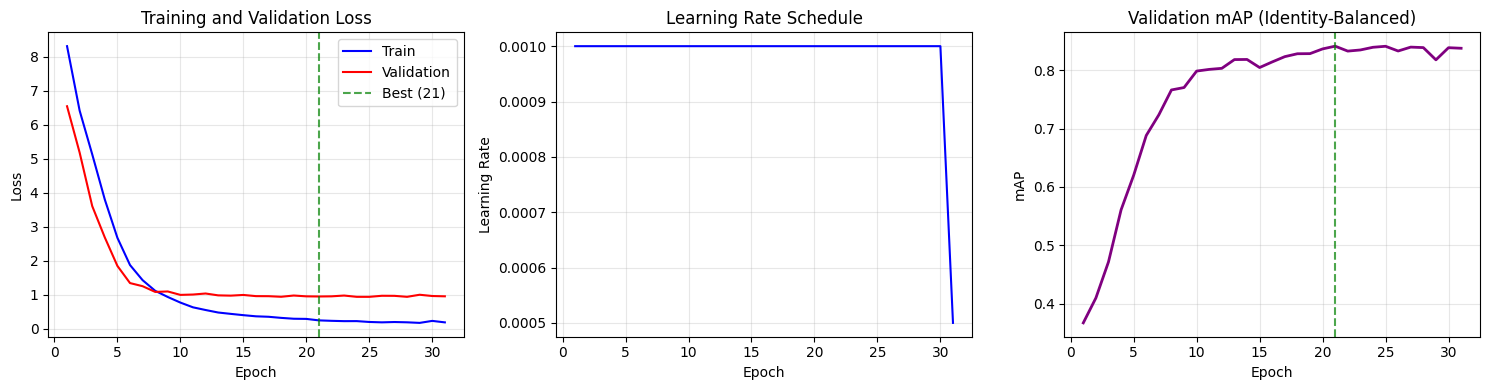

In [36]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_nadam.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_nadam": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(nadam_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 21
  Val Loss: 0.9488
  Val mAP: 0.8412


In [38]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


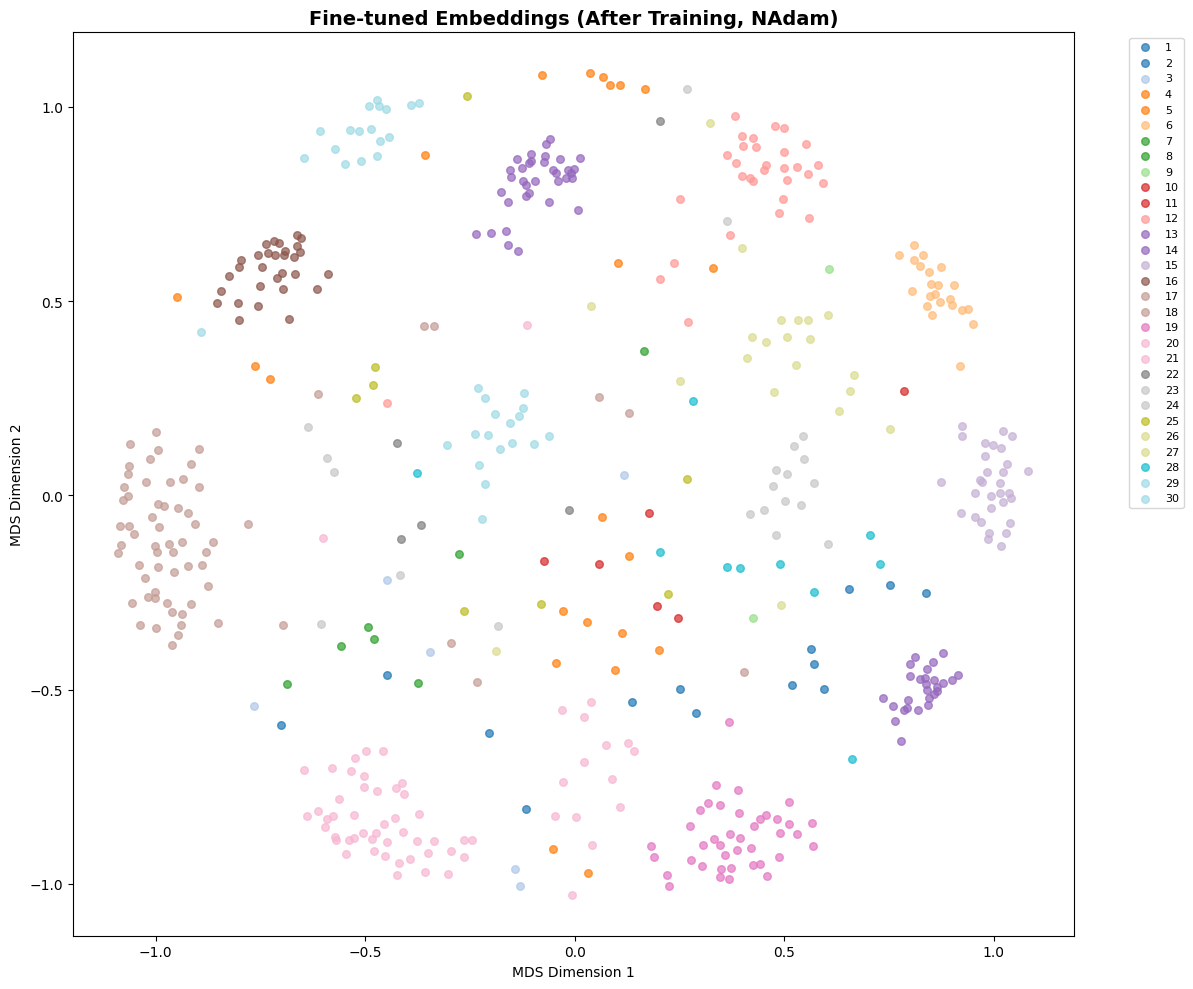

In [39]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, NAdam)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "nadam_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_nadam": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_nadam.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_nadam": wandb.Image(fig),
    "nearest_neighbors_stats_nadam": stats,
})


In [40]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## SGD + Momentum

Stochastic Gradient Descent with Momentum accumulates a running average of past gradients to smooth updates and accelerate optimization in consistent directions. Momentum reduces oscillations and helps the optimizer move faster through shallow regions of the loss landscape.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))
criterion.load_state_dict(torch.load(criterion_checkpoint_path))

optimizer = torch.optim.SGD(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["sgd_learning_rate"],
    weight_decay=config["sgd_weight_decay"],
    momentum=config["sgd_momentum"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"], 
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: SGD (lr={config['sgd_learning_rate']}, weight_decay={config['sgd_weight_decay']}, momentum={config['sgd_momentum']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Optimizer: SGD (lr=0.01, weight_decay=0.0001, momentum=0.9)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
sgd_checkpoint_path = CHECKPOINT_PATH / "best_sgd_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="sgd",
    checkpoint_path=sgd_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_sgd": best_map,
    "best_epoch_sgd": best_epoch,
    "total_epochs_sgd": len(history['train_loss']),
    "training_time_sgd": training_time
})

table.append([
    "SGD",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 334 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.5261
  Val Loss:   2.9674
  Val mAP:    0.3670 | LR: 1.00e-02
  [New best model saved]

Epoch 2/200


  Train Loss: 3.6617
  Val Loss:   1.5554
  Val mAP:    0.4928 | LR: 1.00e-02
  [New best model saved]

Epoch 3/200


  Train Loss: 2.3698
  Val Loss:   1.3728
  Val mAP:    0.5871 | LR: 1.00e-02
  [New best model saved]

Epoch 4/200


  Train Loss: 1.7899
  Val Loss:   1.2445
  Val mAP:    0.6582 | LR: 1.00e-02
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1925
  Val Loss:   0.9778
  Val mAP:    0.8320 | LR: 1.25e-03
  No improvement. Patience: 6/10

Epoch 47/200


  Train Loss: 0.2047
  Val Loss:   0.9675
  Val mAP:    0.8304 | LR: 1.25e-03
  No improvement. Patience: 7/10

Epoch 48/200


  Train Loss: 0.1925
  Val Loss:   0.9790
  Val mAP:    0.8322 | LR: 6.25e-04
  No improvement. Patience: 8/10

Epoch 49/200


  Train Loss: 0.2109
  Val Loss:   0.9657
  Val mAP:    0.8356 | LR: 6.25e-04
  No improvement. Patience: 9/10

Epoch 50/200


  Train Loss: 0.1992
  Val Loss:   0.9739
  Val mAP:    0.8301 | LR: 6.25e-04
  No improvement. Patience: 10/10

Early stopping triggered after 50 epochs

Training complete!
Best epoch: 40, Val mAP: 0.8362


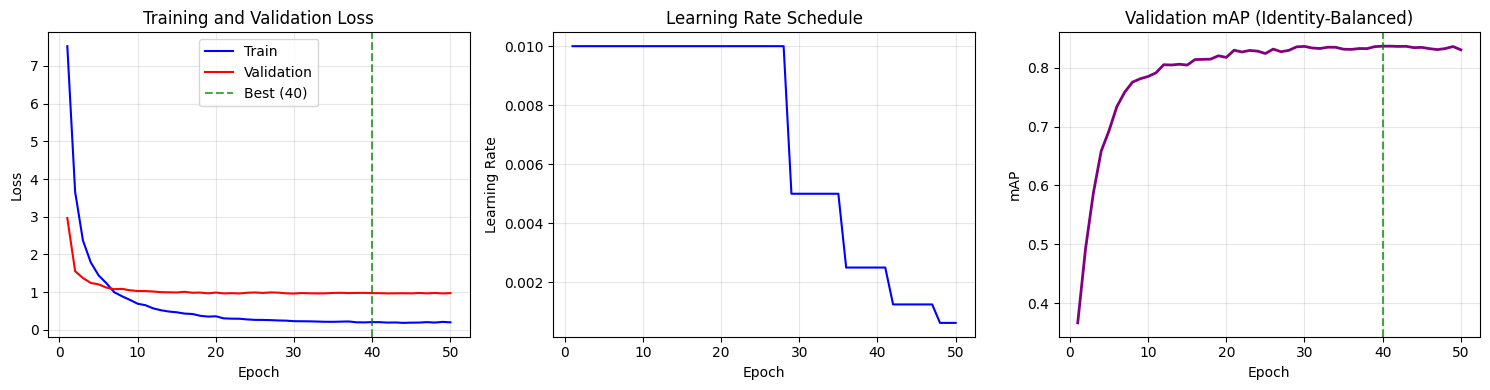

In [43]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sgd": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(sgd_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 40
  Val Loss: 0.9739
  Val mAP: 0.8362


In [45]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


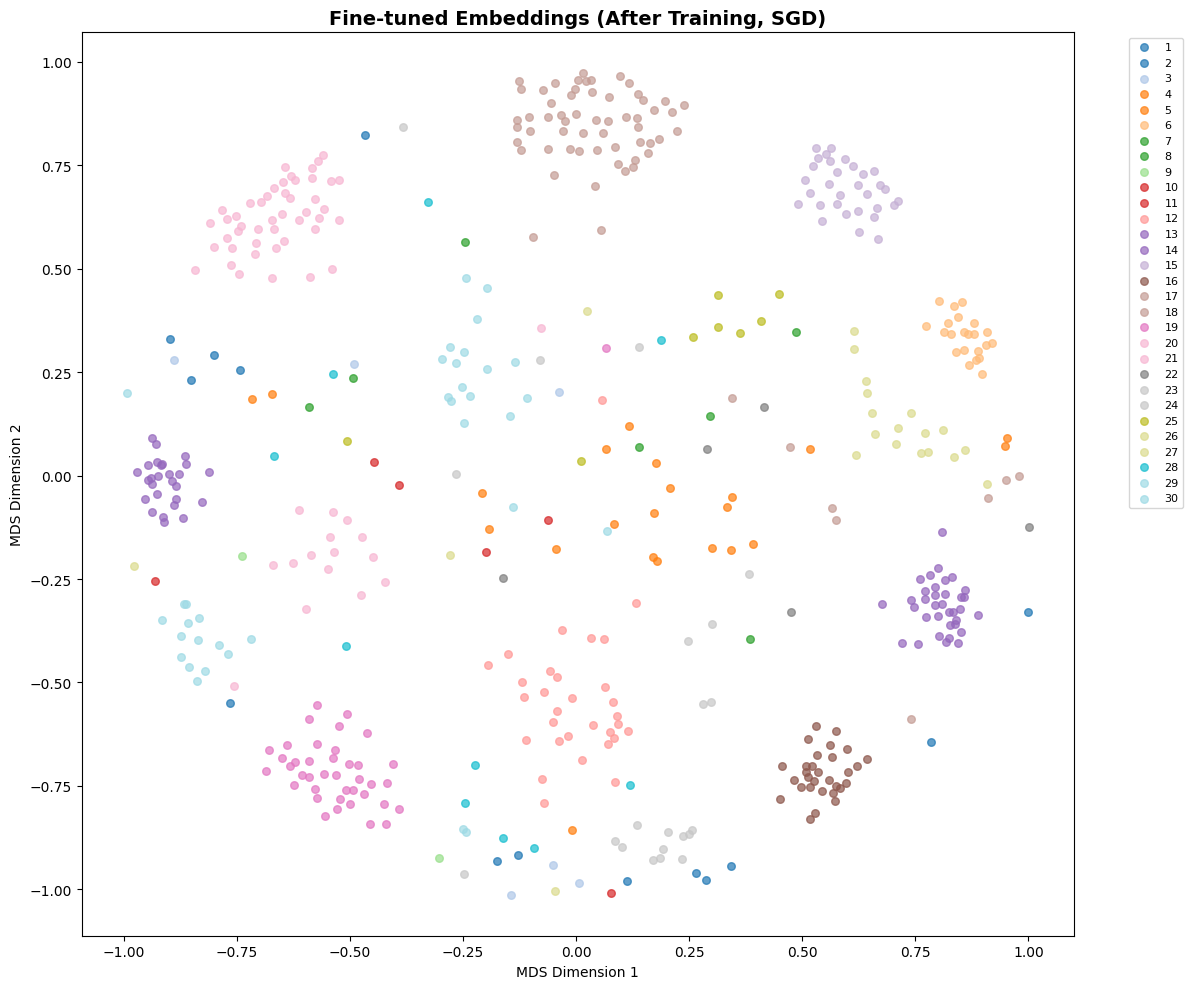

In [46]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, SGD)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sgd_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sgd": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_sgd.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_sgd": wandb.Image(fig),
    "nearest_neighbors_stats_sgd": stats,
})


In [47]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## RMSProb

RMSProp adapts the learning rate for each parameter by dividing the gradient by a running average of its squared values. This prevents overly large updates and helps stabilize training, particularly in problems with noisy or non-stationary gradients.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))
criterion.load_state_dict(torch.load(criterion_checkpoint_path))

optimizer = torch.optim.RMSprop(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["rmsprop_learning_rate"],
    weight_decay=config["rmsprop_weight_decay"],
    momentum=config["rmsprop_momentum"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: RMSprop (lr={config['rmsprop_learning_rate']}, weight_decay={config['rmsprop_weight_decay']}, momentum={config['rmsprop_momentum']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Optimizer: RMSprop (lr=0.001, weight_decay=0.0001, momentum=0.9)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
rms_checkpoint_path = CHECKPOINT_PATH / "best_rmsprop_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="rmsprop",
    checkpoint_path=rms_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_rmsprop": best_map,
    "best_epoch_rmsprop": best_epoch,
    "total_epochs_rmsprop": len(history['train_loss']),
    "training_time_rmsprop": training_time  
})

table.append([
    "RMSprop",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 334 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.7837
  Val Loss:   2.7422
  Val mAP:    0.2530 | LR: 1.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 4.5740
  Val Loss:   2.1605
  Val mAP:    0.3549 | LR: 1.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 3.4224
  Val Loss:   1.8151
  Val mAP:    0.4786 | LR: 1.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 2.6363
  Val Loss:   1.5834
  Val mAP:    0.5666 | LR: 1.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1407
  Val Loss:   0.9957
  Val mAP:    0.8250 | LR: 2.50e-04
  No improvement. Patience: 6/10

Epoch 44/200


  Train Loss: 0.1251
  Val Loss:   0.9817
  Val mAP:    0.8335 | LR: 2.50e-04
  No improvement. Patience: 7/10

Epoch 45/200


  Train Loss: 0.1471
  Val Loss:   0.9785
  Val mAP:    0.8323 | LR: 2.50e-04
  No improvement. Patience: 8/10

Epoch 46/200


  Train Loss: 0.1415
  Val Loss:   0.9393
  Val mAP:    0.8316 | LR: 1.25e-04
  No improvement. Patience: 9/10

Epoch 47/200


  Train Loss: 0.1307
  Val Loss:   0.9362
  Val mAP:    0.8340 | LR: 1.25e-04
  No improvement. Patience: 10/10

Early stopping triggered after 47 epochs

Training complete!
Best epoch: 37, Val mAP: 0.8410


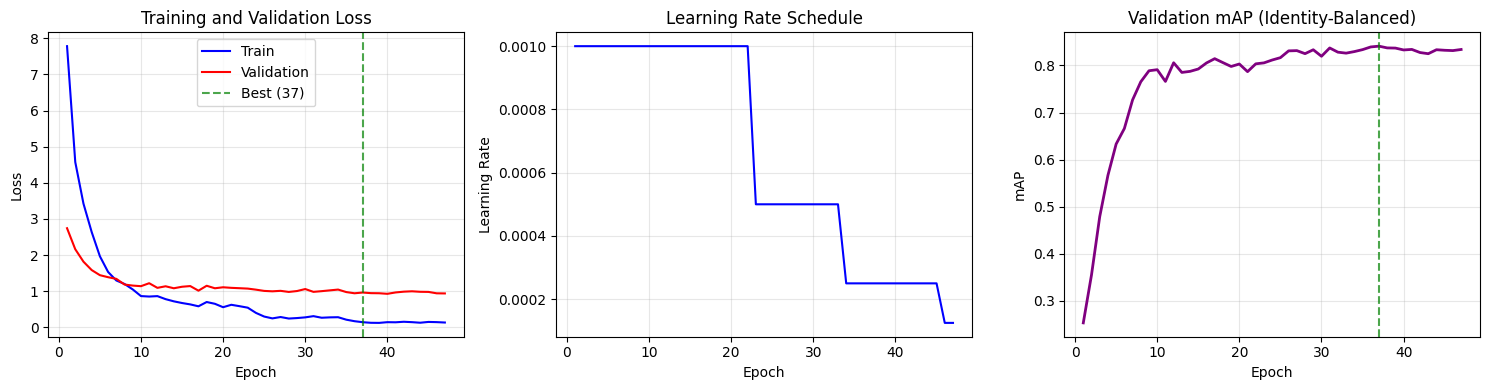

In [50]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_rmsprop.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_rmsprop": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(rms_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 37
  Val Loss: 0.9612
  Val mAP: 0.8410


In [52]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


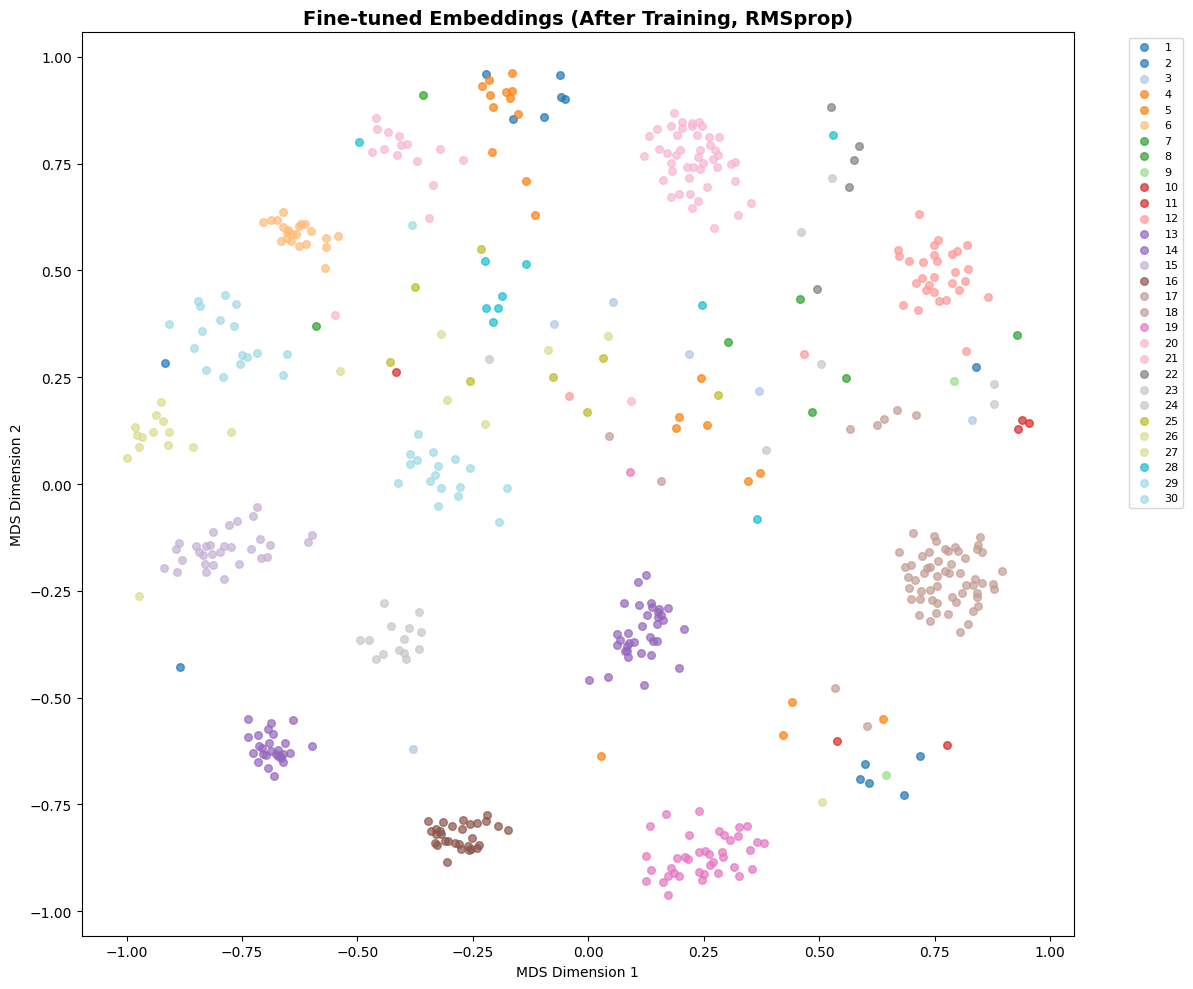

In [53]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, RMSprop)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "rmsprop_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_rmsprop": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_rmsprop.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_rmsprop": wandb.Image(fig),
    "nearest_neighbors_stats_rmsprop": stats,
})


In [54]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [55]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+--------------+----------+-----------+-----------+-----------+-----------+
| Optimizer    |     Adam |     AdamW |     NAdam |       SGD |   RMSprop |
+==============+==========+===========+===========+===========+===========+
| Best val_mAP |  0.85205 |  0.848523 |  0.841158 |  0.836245 |   0.84104 |
+--------------+----------+-----------+-----------+-----------+-----------+
| Best epoch   | 34       | 43        | 21        | 40        |  37       |
+--------------+----------+-----------+-----------+-----------+-----------+


In [ ]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

Result with random seed 12:
| Optimizer    | Adam      | AdamW     | NAdam     | SGD       | RMSprop   |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Best val_mAP | 0.899    | 0.898    | **0.899** | 0.875    | 0.896    |
| Best epoch   | 35        | 34        | 41        | 38        | 44        |

Result with random seed 67:
| Optimizer    | Adam      | AdamW     | NAdam     | SGD       | RMSprop   |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Best val_mAP | 0.850    | 0.856    | 0.857    | 0.841    | **0.866** |
| Best epoch   | 34        | 38        | 33        | 19        | 42        |

Result with random seed 99:
| Optimizer    | Adam      | AdamW     | NAdam     | SGD       | RMSprop   |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Best val_mAP | **0.880**    | 0.877    | 0.880    | 0.866    | 0.877    |
| Best epoch   | 46        | 45        | 43        | 54        | 41        |

Result with random seed 87:
| Optimizer    | Adam      | AdamW     | NAdam     | SGD       | RMSprop   |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Best val_mAP | 0.915     | 0.918     | 0.917     | 0.915     | **0.923** |
| Best epoch   | 20        | 40        | 34        | 50        | 61        |

Result with random seed 334:
| Optimizer    | Adam      | AdamW     | NAdam     | SGD       | RMSprop   |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Best val_mAP | 0.852     | 0.849     | 0.841     | 0.836     | 0.841     |
| Best epoch   | 34        | 43        | 21        | 40        | 37        |

| Rank | Optimizer | Seed 12 | Seed 67 | Seed 99 | Seed 87 | Seed 334 | **Mean mAP** | **Std** |
| ---: | --------- | ------: | ------: | ------: | ------: | -------: | -----------: | ------: |
|    1 | RMSprop   |   0.896 |   0.866 |   0.877 |   0.923 |    0.841 |    **0.880** |   0.031 |
|    2 | AdamW     |   0.898 |   0.856 |   0.877 |   0.918 |    0.849 |    **0.880** |   0.027 |
|    3 | NAdam     |   0.899 |   0.857 |   0.880 |   0.917 |    0.841 |    **0.879** |   0.031 |
|    4 | Adam      |   0.899 |   0.850 |   0.880 |   0.915 |    0.852 |    **0.879** |   0.028 |
|    5 | SGD       |   0.875 |   0.841 |   0.866 |   0.915 |    0.836 |    **0.867** |   0.035 |

Interpretation

RMSprop and AdamW are tied for the highest mean performance (0.880), with RMSprop slightly better in peak values.

NAdam and Adam are very close in mean (~0.879) and have slightly lower variance.

SGD lags behind all adaptive optimizers.

Conclusion: Use RMSprop or AdamW for best average performance, though NAdam and Adam are also strong and slightly more stable.

## Submission

In [ ]:
submission_model = "adamw"

submission_dict = {
    "adam": adam_checkpoint_path,
    "adamw": adamw_checkpoint_path,
    "nadam": nadam_checkpoint_path,
    "sgd": sgd_checkpoint_path,
    "rmsprop": rms_checkpoint_path,
}

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path = submission_dict[submission_model]

wandb.log({"submission_type": submission_model})

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

## Artifacts

In [ ]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"proxyanchor-model-{key}",
        type="model",
        description="ProxyAnchor + Center fine-tuned MegaDescriptor model for jaguar re-identification with Optimizer: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_bg_image,▁
best_epoch_blur_bg,▁
best_epoch_const_bg,▁
best_epoch_extend_fg,▁
best_epoch_noise_bg,▁
best_epoch_sample_fg,▁
epoch,▃▄▅▅▇▁▂▂▄▄▅▆▇▇█▂▂▃▃▄▅▅▇█▁▂▃▃▇▇▁▃▆▇▁▆▇▄▄▆
final_val_mAP_baseline,▁
final_val_mAP_bg_image,▁
+21,...
